# FashionMNIST 흑백 이미지 분류

- **흑백(1채널) 28×28 픽셀** 의류 데이터셋
- 클래스 종류
```python
fashion_mnist_classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
```

## 처리 순서

1. 데이터를 내려받아 Tensor로 전처리한다.
2. CNN 모델을 만들고 logits 10개를 출력한다.
3. 손실함수와 optimizer를 이용해 모델을 학습한다.
4. test 데이터로 성능을 평가한다.
5. 합성곱 계층이 만든 feature map을 관찰한다.

데이터셋 출처: [Fashion-MNIST GitHub](https://github.com/zalandoresearch/fashion-mnist)

## 1. 데이터 준비

### FashionMNIST train·test 데이터 다운로드

`download=True`는 `./data`에 파일이 없을 때 데이터를 자동으로 내려받는다. 이미 받은 데이터가 있으면 저장된 파일을 다시 사용한다.

In [5]:
from torchvision import datasets

train_dataset = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
)

test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
)

print("train 데이터 수:", len(train_dataset))
print("test 데이터 수:", len(test_dataset))


train 데이터 수: 60000
test 데이터 수: 10000


### Dataset 객체 확인

`Dataset`은 이미지와 정답을 한 쌍씩 꺼낼 수 있게 관리한다. 내부 `data`와 `targets`를 보면 전체 이미지와 정답의 shape를 확인할 수 있다.

In [6]:
print(train_dataset)
print(test_dataset)

print("train 이미지 shape:", train_dataset.data.shape)
print("train 정답 shape:", train_dataset.targets.shape)
print("클래스 이름:", train_dataset.classes)


Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
train 이미지 shape: torch.Size([60000, 28, 28])
train 정답 shape: torch.Size([60000])
클래스 이름: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### 이미지 한 장과 label 확인

Dataset에서 `train_dataset[index]`를 사용하면 `(이미지, label)` 한 쌍을 얻는다. 원본 픽셀은 0~255 범위의 정수로 저장되어 있다.

In [7]:
sample_image, sample_label = train_dataset[0]

raw_image = train_dataset.data[0]

print("이미지 객체:", sample_image)
print("label:", sample_label)
print("클래스 이름:", train_dataset.classes[sample_label])
print("원본 shape:", raw_image.shape)
print("원본 dtype:", raw_image.dtype) # unit8 == 부호 없는 8비트 정수

# (검은색) 0 ~ 255 (흰색)
print("픽셀 범위:", raw_image.min().item(), "~", raw_image.max().item())
print(raw_image)

이미지 객체: <PIL.Image.Image image mode=L size=28x28 at 0x21F85A81700>
label: 9
클래스 이름: Ankle boot
원본 shape: torch.Size([28, 28])
원본 dtype: torch.uint8
픽셀 범위: 0 ~ 255
tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
           0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,   1,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,   0,
          36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,   0,   3],
        [  0,   0,   0,   0,   0,   0,   0

### Channel 축 추가와 픽셀 정규화

PyTorch CNN은 이미지를 `(N, C, H, W)` 순서로 받는다.
흑백 이미지에는 `C=1`을 추가하고
학습 과정(신경망의 가중치 계산, 활성화 함수 결과)을 안정적으로 진행하기 위해 픽셀값을 0 ~ 255에서 -1 ~ 1 범위로 바꾼다.

In [8]:
print("전처리 전 shape:", train_dataset.data.shape)

# unsqueeze를 이용해서 흑백 채널을 나타내는 축 값 C = 1 추가
train_images = train_dataset.data.unsqueeze(1).float() / 255.0
test_images = test_dataset.data.unsqueeze(1).float() / 255.0

train_images = (train_images - 0.5) / 0.5
test_images = (test_images - 0.5) / 0.5

# CrossEntropyLoss (다중 분류 손실 함수)는 입력 값이 long(int64) 타입이어야 함
# -> 타입 맞춰주기
train_labels = train_dataset.targets.long()
test_labels = test_dataset.targets.long()

print("전처리 후 shape:", train_images.shape)
print("이미지 dtype:", train_images.dtype)
print(f"픽셀 범위: {train_images.min().item():.1f} ~ {train_images.max().item():.1f}")
print("정답 dtype:", train_labels.dtype)

전처리 전 shape: torch.Size([60000, 28, 28])
전처리 후 shape: torch.Size([60000, 1, 28, 28])
이미지 dtype: torch.float32
픽셀 범위: -1.0 ~ 1.0
정답 dtype: torch.int64


### Train·Validation 데이터 분할

train은 가중치를 학습하는 데이터이고 validation은 학습 중 성능을 점검하는 데이터이다. 공식 train 데이터의 15%를 validation으로 분리한다.

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split

# train 51,000개, validation 9,000개, test 10,000개 준비하는 과정
train_indices, validation_indices = train_test_split(
    np.arange(len(train_images)),
    test_size=0.15,
    random_state=42,
)

tr_images = train_images[train_indices]
tr_labels = train_labels[train_indices]
val_images = train_images[validation_indices]
val_labels = train_labels[validation_indices]

print("train:", tr_images.shape, tr_labels.shape)
print("validation:", val_images.shape, val_labels.shape)
print("test:", test_images.shape, test_labels.shape)


train: torch.Size([51000, 1, 28, 28]) torch.Size([51000])
validation: torch.Size([9000, 1, 28, 28]) torch.Size([9000])
test: torch.Size([10000, 1, 28, 28]) torch.Size([10000])


## 2. 데이터 시각화

### 무작위 의류 이미지 확인

학습 전에 이미지와 label이 올바르게 연결됐는지 확인한다. 화면에 표시할 때는 -1~1로 정규화한 값을 다시 0~1로 되돌린다.

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
tensor([9, 8, 2, 4, 5, 1, 6, 5, 8, 0])
Ankle boot


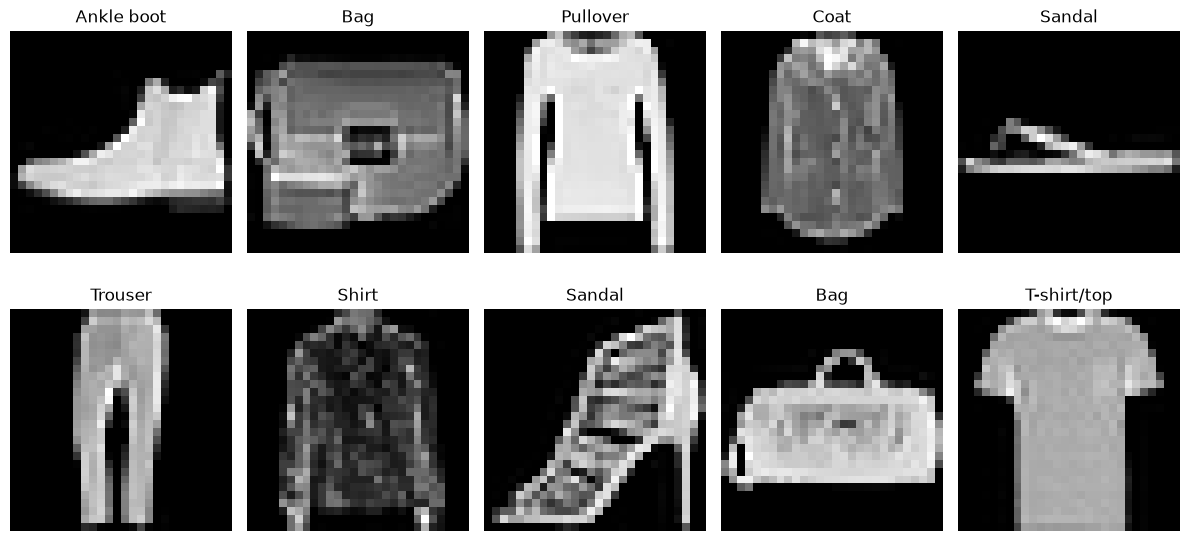

In [10]:
import matplotlib.pyplot as plt

class_names = train_dataset.classes
print(class_names)

random_generator = np.random.default_rng(42)
random_indices = random_generator.choice(len(tr_images), 10, replace=False)
random_images = tr_images[random_indices]
random_labels = tr_labels[random_indices]
print(random_labels)
print(class_names[random_labels[0]])

plt.figure(figsize=(12, 6))

for index in range(10):
    plt.subplot(2, 5, index + 1)

    display_image = random_images[index].squeeze(0) * 0.5 + 0.5
    label_index = random_labels[index].item()

    plt.imshow(display_image, cmap="gray")
    plt.title(class_names[label_index])
    plt.axis("off")

plt.tight_layout()
plt.show()


## 3. CNN 모델 생성

### FashionMNISTCNN 클래스 정의

합성곱 계층은 이미지 특징을 찾고, 완전연결 계층은 찾은 특징으로 10개 클래스를 분류한다. 마지막 출력은 확률이 아닌 **logits 10개**이다.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# torch를 이용해서 딥러닝 모델, DataLoader 이용 시
# 초기 가중치, 데이터 load 순서를 고정
torch.manual_seed(42)

# CNN 모델 생성
class FashionMNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # 첫번째 합성곱 층 생성
        # - N개의 이미지 흑백(1채널), 높이/너비 28px을 받아서 32개의 feature map을 만들어 출력
        # - 출력되는 feature map의 크기 -> 28x28
        self.conv1  = nn.Conv2d(
            in_channels = 1,
            out_channels = 32,
            kernel_size = 3,
            stride = 1,
            padding = 1
        )

        # 두번째 합성곱
        # - 32채널을 받아 64개의 feature map을 출력
        # - padding = 0, stride = 1, kernel_size = 3
        # - 패딩이 없어서 크기가 28x28 -> 26x26 감소
        self.conv2 = nn.Conv2d(
            in_channels = 32,
            out_channels = 64,
            kernel_size=3,
            stride = 1,
            padding = 0
        )

        # 2x2 MaxPool 생성
        # -> 2x2 영역 내 최대값을 추출하여 새 feature map 생성
        # -> 보통 크기가 1/2로 감소
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)

        # FC층에서 사용할 Flatten 생성
        # 다차원 데이터를 1줄로 펼치는 작업
        self.flatten = nn.Flatten()

        # Dropout을 이용해서 학습 효율 높이고, 과적합 방지
        # Dropout == 학습 중에 랜덤하게 뉴런 끄기
        self.dropout1 = nn.Dropout(p = 0.3)

        # in_features 값 : 채널 수 * 높이 * 너비
        # Linear == 특징들을 조합해서 최종 분류 점수 생성
        self.fc1 = nn.Linear(in_features = 64*13*13, out_features = 10)

        self.dropout2 = nn.Dropout(p = 0.3)

        # out_features 값 : 정답(class0의 수 == 마지막으로 출력할 logit 수
        self.fc2 = nn.Linear(in_features = 100, out_features = 10)

    # 순전파
    def forward(self, inputs):
        # Conv2d의 선형 결과를 활성화 함수(ReLU)를 이용해
        # 음수 부분을 0으로 바꾸고 비선형성을 추가
        features = F.relu(self.conv1(inputs)) # (N, 1, 28, 28) -> (N, 32, 28, 28)
        features = F.relu(self.conv2(features)) # (N, 32, 28, 28) -> (N, 64, 26, 26)

        # feature map 크기 감소 == 전체 feature 수 감소
        features = self.pool(features) # (N, 64, 26, 26) -> (N, 64, 13, 13)

        # 평탄화
        flattened = self.flatten(features) # (N, 64, 13, 13) -> (N, 10816)

        hidden = self.dropout1(flattened) # 일부 0으로 변경
        hidden = F.relu(self.fc1(hidden)) # (N, 10816) -> (N, 100)
        hidden = self.dropout2(hidden)

        # 학습 과정에서 사용할 손실함수 CrossEntropyLoss가 내부에 softmax를 가지고 있기 떄문에
        # 별도 활성화 없이 logit 상태로 반환
        logits = self.fc2(hidden) # (N, 100) -> (N, 10)

# 모델 생성
model = FashionMNISTCNN()
print(model)

FashionMNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=10816, out_features=10, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=100, out_features=10, bias=True)
)


### Dummy Input으로 출력 shape 확인

실제 학습 전에 가짜 이미지 batch를 모델에 넣으면 계층의 shape 계산이 맞는지 빠르게 검사할 수 있다. `(4, 10)`은 이미지 4장마다 logit 10개가 나온다는 뜻이다.

In [11]:
dummy_inputs = torch.randn(4, 1, 28, 28)

model.eval()
with torch.no_grad():
    dummy_logits = model(dummy_inputs)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("입력 shape:", dummy_inputs.shape)
print("logits shape:", dummy_logits.shape)
print("학습 가능한 파라미터 수:", trainable_parameters)


NameError: name 'torch' is not defined

## 4. 모델 학습

### DataLoader·손실함수·optimizer 준비

`DataLoader`는 전체 데이터를 작은 mini-batch로 나누어 공급한다. `CrossEntropyLoss`는 logits와 정답 클래스 번호를 비교하고, Adam은 기울기를 이용해 가중치와 편향을 갱신한다.

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

train_tensor_dataset = TensorDataset(tr_images, tr_labels)
validation_tensor_dataset = TensorDataset(val_images, val_labels)
test_tensor_dataset = TensorDataset(test_images, test_labels)

BATCH_SIZE = 128

train_loader = DataLoader(
    train_tensor_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
validation_loader = DataLoader(
    validation_tensor_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    test_tensor_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("device:", device)
print("train batch 수:", len(train_loader))
print("validation batch 수:", len(validation_loader))
print("test batch 수:", len(test_loader))


### Train·Validation 학습 루프

각 epoch마다 `순전파 → 손실 계산 → 역전파 → 가중치 갱신`을 반복한다. 학습 후 validation 성능을 계산해 새로운 데이터에서도 성능이 함께 좋아지는지 확인한다.

### 학습 곡선 시각화

손실과 정확도를 그래프로 보면 학습 진행과 과적합 여부를 숫자 목록보다 쉽게 판단할 수 있다. train과 validation 곡선의 방향과 간격을 함께 본다.

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history["train_acc"], label="train accuracy")
plt.plot(history["val_acc"], label="validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5. 모델 평가

### Test 데이터 성능 측정

test 데이터는 모델 학습과 조정에 사용하지 않고 마지막에 한 번 성능을 확인한다. `eval()`과 `no_grad()`를 사용해 Dropout과 기울기 계산을 끈다.

## 6. 특성맵 시각화

### 특성맵에 사용할 입력 이미지 확인

Feature map은 합성곱 필터가 입력의 어느 부분에 강하게 반응했는지 보여준다. 먼저 모델에 넣을 이미지 한 장과 입력 shape를 확인한다.

In [ ]:
sample_index = 1
sample_input = tr_images[sample_index:sample_index + 1].to(device)

sample_display = tr_images[sample_index].squeeze(0) * 0.5 + 0.5
sample_label_index = tr_labels[sample_index].item()

plt.imshow(sample_display, cmap="gray_r")
plt.title(f"Input: {class_names[sample_label_index]}")
plt.axis("off")
plt.show()

print("모델 입력 shape:", sample_input.shape)


### Forward hook으로 중간 출력 저장

`register_forward_hook`은 모델의 순전파가 실행될 때 특정 계층의 출력을 저장한다. 모델 코드를 바꾸지 않고 `conv1`, `conv2`의 feature map을 관찰할 수 있다.

In [ ]:
class FeatureExtractor:
    def __init__(self, model, layer_name):
        self.model = model
        self.features = None

        layer = dict(model.named_modules())[layer_name]

        self.handle = layer.register_forward_hook(self._save_output)

    def _save_output(self, module, module_inputs, module_output):

        self.features = module_output.detach()

    def get_features(self, inputs):

        self.model.eval()
        with torch.no_grad():
            _ = self.model(inputs)
        return self.features

    def close(self):

        self.handle.remove()


### 첫 번째 합성곱 계층의 feature map

`conv1`은 입력 흑백 이미지에서 서로 다른 32가지 패턴을 찾는다. 각 채널은 하나의 필터가 만든 반응 결과이다.

In [ ]:
conv1_extractor = FeatureExtractor(model, "conv1")
conv1_feature_maps = conv1_extractor.get_features(sample_input)
conv1_extractor.close()

print("conv1 feature map shape:", conv1_feature_maps.shape)

conv1_maps = conv1_feature_maps.cpu().numpy()

figure, axes = plt.subplots(4, 8, figsize=(15, 8))
for row in range(4):
    for column in range(8):
        channel = row * 8 + column

        axes[row, column].imshow(conv1_maps[0, channel], cmap="viridis")
        axes[row, column].set_title(f"Filter {channel}", fontsize=8)
        axes[row, column].axis("off")

plt.suptitle("First Conv Layer Feature Maps")
plt.tight_layout()
plt.show()


### 두 번째 합성곱 계층의 feature map

`conv2`는 `conv1`이 찾은 단순한 특징들을 조합해 64개 feature map을 만든다. padding이 없기 때문에 공간 크기는 28×28에서 26×26으로 줄어든다.

In [ ]:
conv2_extractor = FeatureExtractor(model, "conv2")
conv2_feature_maps = conv2_extractor.get_features(sample_input)
conv2_extractor.close()

print("conv2 feature map shape:", conv2_feature_maps.shape)

conv2_maps = conv2_feature_maps.cpu().numpy()

figure, axes = plt.subplots(8, 8, figsize=(12, 12))
for row in range(8):
    for column in range(8):
        channel = row * 8 + column
        axes[row, column].imshow(conv2_maps[0, channel], cmap="viridis")
        axes[row, column].set_title(f"Filter {channel}", fontsize=6)
        axes[row, column].axis("off")

plt.suptitle("Second Conv Layer Feature Maps")
plt.tight_layout()
plt.show()


## 핵심 정리

- 흑백 이미지 한 장은 `(C=1, H=28, W=28)`, mini-batch는 `(N, 1, 28, 28)` 형태이다.
- CNN은 합성곱으로 특징을 찾고 pooling으로 공간 크기를 줄인 뒤 Linear 계층으로 분류한다.
- 마지막 계층은 Softmax를 적용하지 않은 logits 10개를 출력하며 `CrossEntropyLoss`가 이를 정답과 비교한다.
- 학습에서는 `train()`, 역전파, optimizer 갱신을 사용하고 평가에서는 `eval()`과 `no_grad()`를 사용한다.
- feature map을 보면 각 합성곱 필터가 입력 이미지의 서로 다른 특징에 반응한다는 것을 확인할 수 있다.